In [1]:
import laspy as lp
import numpy as np
import open3d as o3d
import laspy
import matplotlib.pyplot as plt

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [20]:
input_path = '../data/als/'
dataname = 'plot_01.las'
point_cloud=lp.read(input_path+dataname)


In [5]:
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(np.vstack((point_cloud.x, point_cloud.y, point_cloud.z)).transpose())
pcd.colors = o3d.utility.Vector3dVector(np.vstack((point_cloud.red, point_cloud.green, point_cloud.blue)).transpose()/65535)

In [6]:
v_size=round(max(pcd.get_max_bound()-pcd.get_min_bound())*0.005,4)
voxel_grid=o3d.geometry.VoxelGrid.create_from_point_cloud(pcd,voxel_size=v_size)

In [7]:
voxel_grid=o3d.geometry.VoxelGrid.create_from_point_cloud(pcd,voxel_size=v_size)

In [8]:
o3d.visualization.draw_geometries([voxel_grid])


In [9]:
voxels=voxel_grid.get_voxels()

In [10]:
vox_mesh=o3d.geometry.TriangleMesh()

In [11]:
for v in voxels:
   cube=o3d.geometry.TriangleMesh.create_box(width=1, height=1,
   depth=1)
   cube.paint_uniform_color(v.color)
   cube.translate(v.grid_index, relative=False)
   vox_mesh+=cube

In [12]:
vox_mesh.translate([0.5,0.5,0.5], relative=True)

TriangleMesh with 565776 points and 848664 triangles.

In [14]:
vox_mesh.scale(v_size, [0,0,0])

TriangleMesh with 565776 points and 848664 triangles.

In [15]:
vox_mesh.translate(voxel_grid.origin, relative=True)

TriangleMesh with 565776 points and 848664 triangles.

In [16]:
vox_mesh.merge_close_vertices(0.0000001)

TriangleMesh with 235155 points and 848664 triangles.

In [17]:
o3d.visualization.draw_geometries([vox_mesh], window_name="Voxelized Mesh")


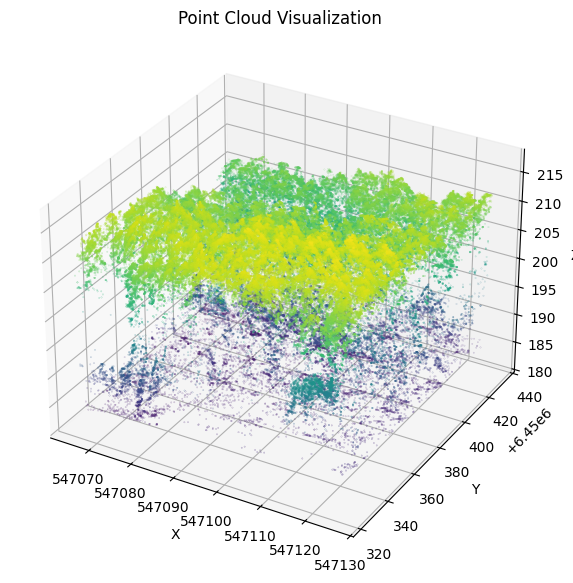

In [22]:
import laspy
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Read the LAS file using laspy
las = laspy.read(input_path+dataname)

# Extract the point cloud coordinates
x = las.x
y = las.y
z = las.z

# If your LAS file includes color information (e.g., RGB), you can also extract it
r = las.red
g = las.green
b = las.blue

# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, s=0.1, c=z, cmap='viridis', marker='.')

# Label the axes for clarity
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.title("Point Cloud Visualization")
plt.show()


Voxel grid dimensions: (62, 111, 35)


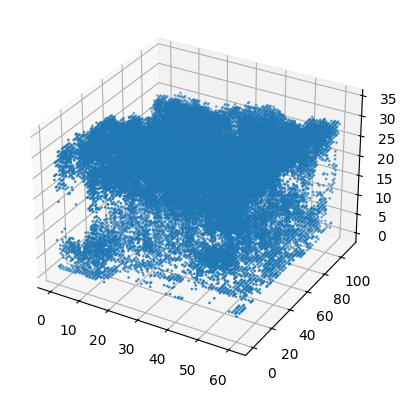

In [30]:
import laspy
import numpy as np

# Step 1: Load the point cloud
las_file = laspy.read(input_path+dataname)
points = np.vstack((las_file.x, las_file.y, las_file.z)).T

# Step 2: Define voxel grid parameters
voxel_size = 1.0  # Example: 1 meter resolution
min_bounds = np.min(points, axis=0)
max_bounds = np.max(points, axis=0)

grid_dimensions = np.ceil((max_bounds - min_bounds) / voxel_size).astype(int)

# Step 3: Create voxel grid
voxel_grid = np.zeros(grid_dimensions, dtype=bool)

# Quantize points to grid
indices = ((points - min_bounds) / voxel_size).astype(int)

# Mark occupied voxels
for index in indices:
    voxel_grid[tuple(index)] = True

# Step 4: Export or visualize
# Optionally, you can save or visualize the voxel grid
print(f"Voxel grid dimensions: {voxel_grid.shape}")

# Visualization (Optional)
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
voxel_coords = np.argwhere(voxel_grid)
ax.scatter(voxel_coords[:, 0], voxel_coords[:, 1], voxel_coords[:, 2], s=1)
plt.show()
